In [ ]:
!pip install linearmodels -q
!pip install statsmodels -q
print('✅  Dependencies installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 18.5 MB/s eta 0:00:00
✅  Dependencies installed.


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print('✅  Drive mounted.')

Mounted at /content/drive
✅  Drive mounted.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
import warnings, os, shutil
warnings.filterwarnings('ignore')
np.random.seed(42)   # reproducibility
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:,.4f}'.format)

# ── PATHS ────────────────────────────────────────────────────────────────────
PANEL_PATH  = '/content/drive/MyDrive/MTA/clean_data/mta_crz_did_panel_raw_hourly_2024_2025.csv'
LOCAL_PATH  = '/content/mta_panel.csv'    # local SSD copy — avoids Drive OSError
ACS_PATH    = '/content/drive/MyDrive/MTA/clean_data/mta_crz_acs_station_joined.csv'
OUT_DIR     = '/content/drive/MyDrive/MTA/clean_data/'

OUT_MC_CSV       = OUT_DIR + 'mta_crz_monte_carlo_station_ci.csv'
OUT_MC_RAW_CSV   = OUT_DIR + 'mta_crz_monte_carlo_raw.csv'
OUT_FOREST_PNG   = OUT_DIR + 'monte_carlo_forest_plot.png'
OUT_MAP_CSV      = OUT_DIR + 'mta_crz_dashboard_station_map.csv'

# ── CONSTANTS ─────────────────────────────────────────────────────────────────
CP_DATE    = pd.Timestamp('2025-01-05')   # CRZ go-live
PRE_START  = pd.Timestamp('2024-01-01')
PRE_END    = pd.Timestamp('2025-01-04')
POST_END   = pd.Timestamp('2025-12-31')
N_SIMS     = 1000                          # bootstrap iterations

# Model B DiD coefficient from the Core DiD notebook
# ✏️  Update these if you re-ran Model B and got different values
MODEL_B_COEF    = -0.205875
MODEL_B_CI_LOW  = -0.2985    # approximate — update from your Model B output
MODEL_B_CI_HIGH = -0.1132    # approximate — update from your Model B output
MODEL_B_PCT     = (np.exp(MODEL_B_COEF) - 1) * 100

CAT_COLS = [
    'station_complex','borough','CRZ_Zone','Day_of_Week',
    'fare_class_category','Division','Line',
    'Daytime_Routes','Structure','time_of_day'
]

def section(title):
    print(f"\n{'='*65}\n  {title}\n{'='*65}")

def check(condition, msg_fail, msg_pass=None):
    if not condition:
        raise AssertionError(f'\n❌  {msg_fail}')
    if msg_pass:
        print(f'  ✅  {msg_pass}')

print('✅  Config loaded.')
print(f'    CP_DATE        : {CP_DATE.date()}')
print(f'    N_SIMS         : {N_SIMS:,}')
print(f'    Model B coeff  : {MODEL_B_COEF:+.6f}  ({MODEL_B_PCT:+.2f}%)')
print(f'    Output dir     : {OUT_DIR}')

✅  Config loaded.
    CP_DATE        : 2025-01-05
    N_SIMS         : 1,000
    Model B coeff  : -0.205875  (-18.61%)
    Output dir     : /content/drive/MyDrive/MTA/clean_data/


In [ ]:
section('1 · LOAD PANEL → DAILY STATION TOTALS')

# Copy to local disk if not already there (avoids Drive OSError on 11GB file)
if not os.path.exists(LOCAL_PATH):
    print('  Copying CSV to local Colab disk (~2 min)...')
    shutil.copy(PANEL_PATH, LOCAL_PATH)
    print(f'  ✅  Copied to {LOCAL_PATH}')
else:
    print(f'  ✅  Local copy exists at {LOCAL_PATH}')

print('  Loading from local disk...')
df = pd.read_csv(LOCAL_PATH, parse_dates=['Date'])

for col in CAT_COLS:
    if col in df.columns:
        df[col] = df[col].astype('category')
for col in ['treated','post','did_term']:
    if col in df.columns:
        df[col] = df[col].astype('int8')

# Fix 1: cast station_complex_id to str before any groupby
df['station_complex_id'] = df['station_complex_id'].astype(str)
# Fix 2: drop station 222 (Roosevelt Island duplicate)
df = df[df['station_complex_id'] != '222'].copy()

EXPECTED_STATIONS = df['station_complex_id'].nunique()
print(f'  Rows loaded       : {len(df):,}')
print(f'  Stations          : {EXPECTED_STATIONS}')
print(f'  Date range        : {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'  treated==1 stns   : {df[df["treated"]==1]["station_complex_id"].nunique()}')
print(f'  treated==0 stns   : {df[df["treated"]==0]["station_complex_id"].nunique()}')

# ── Aggregate to daily station totals ────────────────────────────────────────
print('\n  Aggregating to daily station totals...')
daily = (
    df.groupby(['station_complex_id','Date','treated','post'])
    .agg(
        daily_ridership = ('ridership',         'sum'),
        day_of_week     = ('Day_of_Week',        lambda x: str(x.iloc[0])),
        borough         = ('borough',            lambda x: str(x.iloc[0])),
        station_complex = ('station_complex',    lambda x: str(x.iloc[0])),
        latitude        = ('latitude',           'first'),
        longitude       = ('longitude',          'first'),
    )
    .reset_index()
)

# Date features for trend model
daily['date_index']   = (daily['Date'] - daily['Date'].min()).dt.days
daily['quarter']      = daily['Date'].dt.to_period('Q').astype(str)
daily['is_weekend']   = daily['day_of_week'].isin(['Saturday','Sunday']).astype(int)
daily['month']        = daily['Date'].dt.month
daily['log_ridership']= np.log1p(daily['daily_ridership'])

# Split pre and post
daily_pre  = daily[daily['Date'] <= PRE_END].copy()
daily_post = daily[daily['Date'] >= CP_DATE].copy()

print(f'  Daily panel rows  : {len(daily):,}')
print(f'  Pre-period rows   : {len(daily_pre):,}  ({PRE_START.date()} → {PRE_END.date()})')
print(f'  Post-period rows  : {len(daily_post):,}  ({CP_DATE.date()} → {POST_END.date()})')

dupes = daily.duplicated(subset=['station_complex_id','Date']).sum()
check(dupes == 0,
      f'{dupes:,} duplicate station×date pairs in daily panel.',
      'No duplicate station×date pairs ✓')

print('\n  ✅  Section 1 complete.')


  1 · LOAD PANEL → DAILY STATION TOTALS
  Copying CSV to local Colab disk (~2 min)...
  ✅  Copied to /content/mta_panel.csv
  Loading from local disk...
  Rows loaded       : 57,349,810
  Stations          : 427
  Date range        : 2024-01-01 → 2025-12-31
  treated==1 stns   : 65
  treated==0 stns   : 362

  Aggregating to daily station totals...
  Daily panel rows  : 310,464
  Pre-period rows   : 157,708  (2024-01-01 → 2025-01-04)
  Post-period rows  : 152,756  (2025-01-05 → 2025-12-31)
  ✅  No duplicate station×date pairs ✓

  ✅  Section 1 complete.


In [ ]:
section('2 · PRE-PERIOD TREND FITTING PER STATION')

station_models  = {}   # fitted OLS model per station
station_residuals = {} # pre-period residuals per station
failed_stations = []

stations_list = daily_pre['station_complex_id'].unique()
print(f'  Fitting trend models for {len(stations_list)} stations...')

for i, sid in enumerate(stations_list):
    pre_stn = daily_pre[daily_pre['station_complex_id'] == sid].copy()

    # Need enough data to fit — skip if fewer than 30 pre-period days
    if len(pre_stn) < 30:
        failed_stations.append(sid)
        continue

    # Need variation in ridership
    if pre_stn['log_ridership'].std() < 1e-6:
        failed_stations.append(sid)
        continue

    try:
        # Trend model: log ridership ~ linear time + weekend + month FE
        model = smf.ols(
            'log_ridership ~ date_index + is_weekend + C(month)',
            data=pre_stn
        ).fit()

        station_models[sid]    = model
        station_residuals[sid] = model.resid.values   # pre-period residuals

    except Exception as e:
        failed_stations.append(sid)

    if (i + 1) % 50 == 0:
        print(f'    Fitted {i+1}/{len(stations_list)} stations...')

fitted_count = len(station_models)
print(f'\n  Successfully fitted : {fitted_count} stations')
print(f'  Failed / skipped    : {len(failed_stations)} stations')
if failed_stations:
    print(f'  Failed IDs          : {failed_stations[:10]}{"..." if len(failed_stations)>10 else ""}')

check(fitted_count >= EXPECTED_STATIONS * 0.95,
      f'Only {fitted_count}/{EXPECTED_STATIONS} stations fitted — check pre-period data.',
      f'{fitted_count}/{EXPECTED_STATIONS} stations fitted ✓')

# Show R² distribution across stations
r2_values = [m.rsquared for m in station_models.values()]
print(f'\n  R² across stations:')
print(f'    Mean   : {np.mean(r2_values):.3f}')
print(f'    Median : {np.median(r2_values):.3f}')
print(f'    Min    : {np.min(r2_values):.3f}')
print(f'    Max    : {np.max(r2_values):.3f}')
if np.mean(r2_values) < 0.3:
    print('  ⚠️   Mean R² < 0.3 — trend models explain limited variance.')
    print('       This is expected for some stations with irregular patterns.')
    print('       Bootstrap CIs will be wider for those stations.')
else:
    print('  ✅  Trend models fit well.')

print('\n  ✅  Section 2 complete.')


  2 · PRE-PERIOD TREND FITTING PER STATION
  Fitting trend models for 427 stations...
    Fitted 50/427 stations...
    Fitted 100/427 stations...
    Fitted 150/427 stations...
    Fitted 200/427 stations...
    Fitted 250/427 stations...
    Fitted 300/427 stations...
    Fitted 350/427 stations...
    Fitted 400/427 stations...

  Successfully fitted : 427 stations
  Failed / skipped    : 0 stations
  ✅  427/427 stations fitted ✓

  R² across stations:
    Mean   : 0.492
    Median : 0.457
    Min    : 0.082
    Max    : 0.858
  ✅  Trend models fit well.

  ✅  Section 2 complete.


In [ ]:
section('3 · POST-PERIOD POINT ESTIMATES (actual vs counterfactual)')

point_estimates = []

for sid, model in station_models.items():
    post_stn = daily_post[daily_post['station_complex_id'] == sid].copy()

    if len(post_stn) == 0:
        continue

    # Predict counterfactual: what the trend model says ridership would be
    try:
        counterfactual_log = model.predict(post_stn)
    except Exception:
        # Some month categories may be missing in post-period
        # Fall back to trend-only prediction
        post_stn_safe = post_stn.copy()
        post_stn_safe['month'] = post_stn_safe['month'].clip(
            upper=daily_pre['month'].max()
        )
        try:
            counterfactual_log = model.predict(post_stn_safe)
        except Exception:
            continue

    actual_log        = post_stn['log_ridership'].values
    effect_log        = actual_log - counterfactual_log.values
    mean_effect_log   = effect_log.mean()
    mean_effect_pct   = (np.exp(mean_effect_log) - 1) * 100

    # Station metadata
    meta = daily[daily['station_complex_id'] == sid].iloc[0]
    treated = int(daily[daily['station_complex_id'] == sid]['treated'].iloc[0])

    point_estimates.append({
        'station_complex_id' : sid,
        'station_complex'    : meta['station_complex'],
        'borough'            : meta['borough'],
        'latitude'           : meta['latitude'],
        'longitude'          : meta['longitude'],
        'treated'            : treated,
        'n_pre_days'         : len(station_residuals[sid]),
        'n_post_days'        : len(post_stn),
        'point_effect_log'   : mean_effect_log,
        'point_effect_pct'   : mean_effect_pct,
    })

pe_df = pd.DataFrame(point_estimates)

print(f'  Stations with point estimates : {len(pe_df)}')
print(f'  Treated stations              : {pe_df["treated"].sum()}')
print(f'  Control stations              : {(pe_df["treated"]==0).sum()}')
print()
print(f'  Point estimate distribution (% change):')
print(f'    Mean   treated  : {pe_df[pe_df["treated"]==1]["point_effect_pct"].mean():+.2f}%')
print(f'    Mean   control  : {pe_df[pe_df["treated"]==0]["point_effect_pct"].mean():+.2f}%')
print(f'    Overall mean    : {pe_df["point_effect_pct"].mean():+.2f}%')
print(f'    Overall median  : {pe_df["point_effect_pct"].median():+.2f}%')
print(f'    Overall min     : {pe_df["point_effect_pct"].min():+.2f}%')
print(f'    Overall max     : {pe_df["point_effect_pct"].max():+.2f}%')

print('\n  ✅  Section 3 complete.')


  3 · POST-PERIOD POINT ESTIMATES (actual vs counterfactual)
  Stations with point estimates : 427
  Treated stations              : 65
  Control stations              : 362

  Point estimate distribution (% change):
    Mean   treated  : -8.49%
    Mean   control  : +35.63%
    Overall mean    : +28.91%
    Overall median  : +15.70%
    Overall min     : -87.43%
    Overall max     : +800.01%

  ✅  Section 3 complete.


In [ ]:
section(f'4 · MONTE CARLO BOOTSTRAP ({N_SIMS:,} SIMULATIONS PER STATION)')

mc_results   = []   # final CI per station
mc_raw_rows  = []   # raw simulation draws (for dashboard Monte Carlo slider)

pe_lookup = pe_df.set_index('station_complex_id')
station_ids = list(station_models.keys())

print(f'  Running {N_SIMS:,} simulations for {len(station_ids)} stations...')
print(f'  (This takes ~3–8 min depending on Colab runtime)')

for i, sid in enumerate(station_ids):
    if sid not in pe_lookup.index:
        continue

    model        = station_models[sid]
    pre_residuals= station_residuals[sid]
    post_stn     = daily_post[daily_post['station_complex_id'] == sid].copy()

    if len(post_stn) == 0 or len(pre_residuals) < 5:
        continue

    # Counterfactual (trend prediction for post-period)
    try:
        counterfactual_log = model.predict(post_stn).values
    except Exception:
        post_stn_safe = post_stn.copy()
        post_stn_safe['month'] = post_stn_safe['month'].clip(
            upper=daily_pre['month'].max()
        )
        try:
            counterfactual_log = model.predict(post_stn_safe).values
        except Exception:
            continue

    actual_log = post_stn['log_ridership'].values
    n_post     = len(actual_log)

    # Bootstrap
    sim_effects = np.empty(N_SIMS)
    for s in range(N_SIMS):
        noise          = np.random.choice(pre_residuals, size=n_post, replace=True)
        noisy_cf       = counterfactual_log + noise
        sim_effects[s] = (actual_log - noisy_cf).mean()

    ci_low_log  = np.percentile(sim_effects, 2.5)
    ci_high_log = np.percentile(sim_effects, 97.5)
    mean_effect = sim_effects.mean()

    mc_results.append({
        'station_complex_id' : sid,
        'mc_effect_log'      : mean_effect,
        'mc_effect_pct'      : (np.exp(mean_effect) - 1) * 100,
        'mc_ci_low_log'      : ci_low_log,
        'mc_ci_high_log'     : ci_high_log,
        'mc_ci_low_pct'      : (np.exp(ci_low_log)  - 1) * 100,
        'mc_ci_high_pct'     : (np.exp(ci_high_log) - 1) * 100,
        'ci_width_pct'       : (np.exp(ci_high_log) - np.exp(ci_low_log)) * 100,
        'n_pre_days'         : len(pre_residuals),
        'n_post_days'        : n_post,
        'n_sims'             : N_SIMS,
    })

    # Store a sample of raw draws for the dashboard Monte Carlo slider
    # (store every 10th simulation to keep file size manageable)
    for s_idx in range(0, N_SIMS, 10):
        mc_raw_rows.append({
            'station_complex_id': sid,
            'sim_idx'           : s_idx,
            'effect_log'        : sim_effects[s_idx],
            'effect_pct'        : (np.exp(sim_effects[s_idx]) - 1) * 100,
        })

    if (i + 1) % 50 == 0:
        print(f'    Completed {i+1}/{len(station_ids)} stations...')

mc_df = pd.DataFrame(mc_results)

print(f'\n  Stations with MC results : {len(mc_df)}')
print(f'  MC effect distribution (%):')
treated_mc = mc_df[mc_df['station_complex_id'].isin(
    pe_df[pe_df['treated']==1]['station_complex_id']
)]
control_mc = mc_df[mc_df['station_complex_id'].isin(
    pe_df[pe_df['treated']==0]['station_complex_id']
)]
print(f'    Treated mean effect  : {treated_mc["mc_effect_pct"].mean():+.2f}%')
print(f'    Control mean effect  : {control_mc["mc_effect_pct"].mean():+.2f}%')
print(f'    Overall mean CI width: {mc_df["ci_width_pct"].mean():.2f} pp')
print(f'    Narrowest CI         : {mc_df["ci_width_pct"].min():.2f} pp')
print(f'    Widest CI            : {mc_df["ci_width_pct"].max():.2f} pp')

print('\n  ✅  Section 4 complete.')


  4 · MONTE CARLO BOOTSTRAP (1,000 SIMULATIONS PER STATION)
  Running 1,000 simulations for 427 stations...
  (This takes ~3–8 min depending on Colab runtime)
    Completed 50/427 stations...
    Completed 100/427 stations...
    Completed 150/427 stations...
    Completed 200/427 stations...
    Completed 250/427 stations...
    Completed 300/427 stations...
    Completed 350/427 stations...
    Completed 400/427 stations...

  Stations with MC results : 427
  MC effect distribution (%):
    Treated mean effect  : -8.50%
    Control mean effect  : +35.62%
    Overall mean CI width: 13.53 pp
    Narrowest CI         : 1.78 pp
    Widest CI            : 137.68 pp

  ✅  Section 4 complete.


In [ ]:
section('5 · MERGE ENRICHMENT + BUILD FINAL RESULTS TABLE')

# Merge MC results onto point estimates
final = pe_df.merge(mc_df, on='station_complex_id', how='left')

# Load ACS enrichment
enrichment = pd.read_csv(ACS_PATH)
enrichment['station_complex_id'] = enrichment['station_complex_id'].astype(str)

final = final.merge(
    enrichment[['station_complex_id','CRZ_Zone','GEOID',
                'car_ownership_rate','zero_vehicle_share',
                'dist_to_toll_km','nearest_plaza','is_gateway','acs_imputed']],
    on='station_complex_id',
    how='left'
)

# Attach system-level Model B estimates as reference
final['model_b_coef']     = MODEL_B_COEF
final['model_b_ci_low']   = MODEL_B_CI_LOW
final['model_b_ci_high']  = MODEL_B_CI_HIGH
final['model_b_pct']      = MODEL_B_PCT

# Flag: does the station-level MC CI include zero?
# If CI straddles zero, effect is statistically uncertain at 95% level
final['ci_includes_zero'] = (
    (final['mc_ci_low_pct'] < 0) & (final['mc_ci_high_pct'] > 0)
).astype(int)

# Sanity checks
check(final['mc_effect_pct'].isnull().sum() / len(final) < 0.1,
      'More than 10% of stations missing MC results.',
      f'MC coverage: {final["mc_effect_pct"].notna().sum()}/{len(final)} stations ✓')
check(final['car_ownership_rate'].isnull().sum() == 0,
      'Nulls in car_ownership_rate after ACS merge.',
      'No nulls in car_ownership_rate ✓')

print(f'\n  Final table shape    : {final.shape}')
print(f'  Columns              : {list(final.columns)}')
print(f'\n  MC effect summary:')
print(f'  Treated stations with negative MC effect (ridership fell): '
      f'{(final[final["treated"]==1]["mc_effect_pct"] < 0).sum()}')
print(f'  Treated stations with positive MC effect (ridership rose): '
      f'{(final[final["treated"]==1]["mc_effect_pct"] > 0).sum()}')
print(f'  Stations with CI including zero : {final["ci_includes_zero"].sum()}')

print('\n  ✅  Section 5 complete.')


  5 · MERGE ENRICHMENT + BUILD FINAL RESULTS TABLE
  ✅  MC coverage: 427/427 stations ✓
  ✅  No nulls in car_ownership_rate ✓

  Final table shape    : (427, 33)
  Columns              : ['station_complex_id', 'station_complex', 'borough', 'latitude', 'longitude', 'treated', 'n_pre_days_x', 'n_post_days_x', 'point_effect_log', 'point_effect_pct', 'mc_effect_log', 'mc_effect_pct', 'mc_ci_low_log', 'mc_ci_high_log', 'mc_ci_low_pct', 'mc_ci_high_pct', 'ci_width_pct', 'n_pre_days_y', 'n_post_days_y', 'n_sims', 'CRZ_Zone', 'GEOID', 'car_ownership_rate', 'zero_vehicle_share', 'dist_to_toll_km', 'nearest_plaza', 'is_gateway', 'acs_imputed', 'model_b_coef', 'model_b_ci_low', 'model_b_ci_high', 'model_b_pct', 'ci_includes_zero']

  MC effect summary:
  Treated stations with negative MC effect (ridership fell): 42
  Treated stations with positive MC effect (ridership rose): 23
  Stations with CI including zero : 37

  ✅  Section 5 complete.



  6 · VISUALISATION


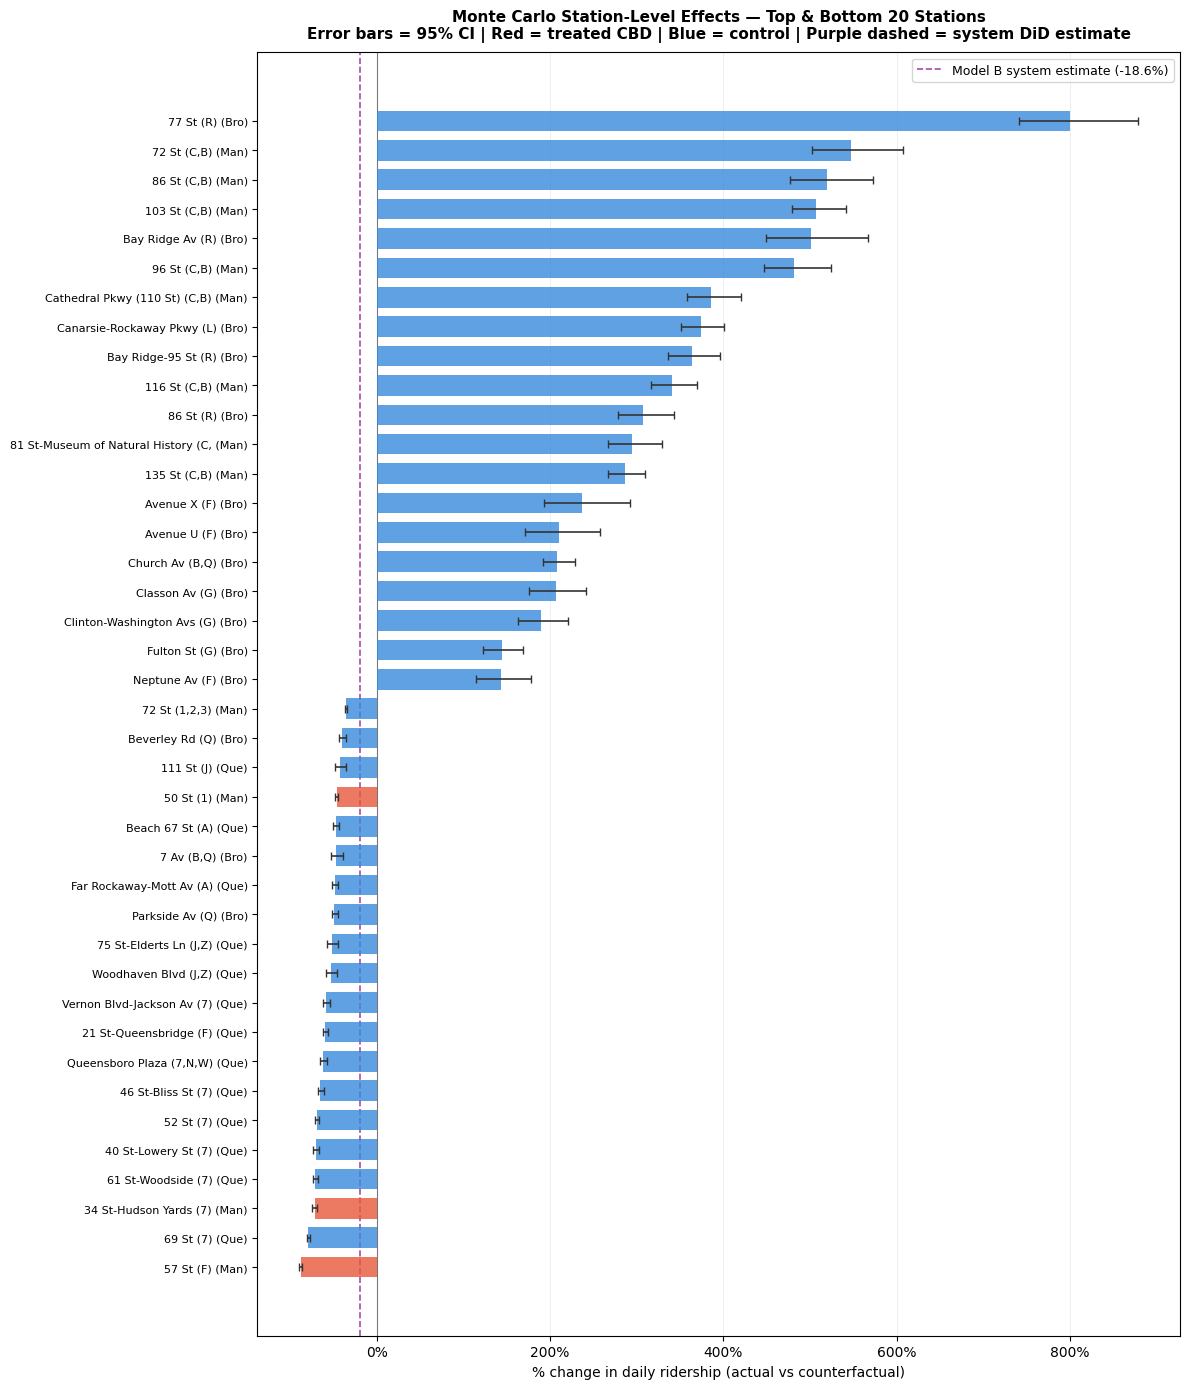

  Saved → /content/drive/MyDrive/MTA/clean_data/monte_carlo_forest_plot.png


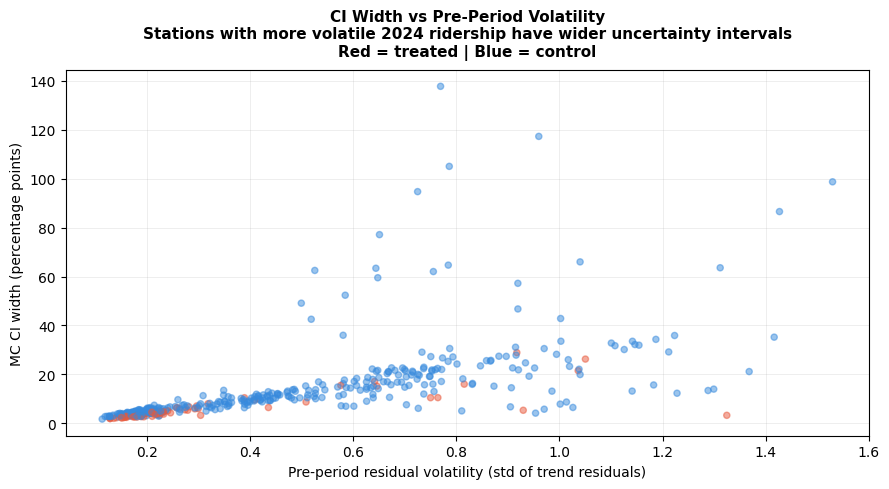

  Saved → /content/drive/MyDrive/MTA/clean_data/monte_carlo_ci_width_plot.png

  ✅  Section 6 complete.


In [ ]:
section('6 · VISUALISATION')

final_clean = final.dropna(subset=['mc_effect_pct','mc_ci_low_pct','mc_ci_high_pct']).copy()

# ── Plot 1: Forest plot — top/bottom 20 stations ──────────────────────────────
top20    = final_clean.nlargest(20,  'mc_effect_pct')
bottom20 = final_clean.nsmallest(20, 'mc_effect_pct')
forest   = pd.concat([top20, bottom20]).drop_duplicates('station_complex_id')
forest   = forest.sort_values('mc_effect_pct')

fig, ax = plt.subplots(figsize=(12, max(8, len(forest) * 0.35)))

colors = [
    '#E8593C' if t == 1 else '#378ADD'
    for t in forest['treated']
]

y_pos = range(len(forest))
ax.barh(
    y_pos, forest['mc_effect_pct'],
    xerr=[
        forest['mc_effect_pct'] - forest['mc_ci_low_pct'],
        forest['mc_ci_high_pct'] - forest['mc_effect_pct']
    ],
    color=colors, alpha=0.8, ecolor='#333',
    error_kw={'elinewidth': 1.2, 'capsize': 3},
    zorder=3, height=0.7
)
ax.axvline(0, color='black', lw=0.8, alpha=0.5)
ax.axvline(MODEL_B_PCT, color='purple', lw=1.2, ls='--', alpha=0.7,
           label=f'Model B system estimate ({MODEL_B_PCT:+.1f}%)')

ax.set_yticks(y_pos)
labels = [
    f"{row['station_complex'][:35]} ({row['borough'][:3]})"
    for _, row in forest.iterrows()
]
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('% change in daily ridership (actual vs counterfactual)', fontsize=10)
ax.set_title(
    'Monte Carlo Station-Level Effects — Top & Bottom 20 Stations\n'
    'Error bars = 95% CI | Red = treated CBD | Blue = control | Purple dashed = system DiD estimate',
    fontsize=11, fontweight='bold', pad=10
)
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3, lw=0.5)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.savefig(OUT_FOREST_PNG, dpi=150, bbox_inches='tight')
plt.show()
print(f'  Saved → {OUT_FOREST_PNG}')

# ── Plot 2: CI width vs pre-period volatility ─────────────────────────────────
# Pre-period volatility = std of residuals from trend model
pre_volatility = {
    sid: np.std(res)
    for sid, res in station_residuals.items()
}
final_clean['pre_volatility'] = final_clean['station_complex_id'].map(pre_volatility)

fig2, ax2 = plt.subplots(figsize=(9, 5))
scatter_colors = [
    '#E8593C' if t == 1 else '#378ADD'
    for t in final_clean['treated']
]
ax2.scatter(
    final_clean['pre_volatility'],
    final_clean['ci_width_pct'],
    c=scatter_colors, alpha=0.5, s=20, zorder=3
)
ax2.set_xlabel('Pre-period residual volatility (std of trend residuals)', fontsize=10)
ax2.set_ylabel('MC CI width (percentage points)', fontsize=10)
ax2.set_title(
    'CI Width vs Pre-Period Volatility\n'
    'Stations with more volatile 2024 ridership have wider uncertainty intervals\n'
    'Red = treated | Blue = control',
    fontsize=11, fontweight='bold', pad=10
)
ax2.grid(alpha=0.3, lw=0.5)
plt.tight_layout()
plt.savefig(OUT_DIR + 'monte_carlo_ci_width_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'  Saved → {OUT_DIR}monte_carlo_ci_width_plot.png')

print('\n  ✅  Section 6 complete.')

In [ ]:
section('7 · EXPORT ALL OUTPUTS')

# ── 1. Main station-level MC results ─────────────────────────────────────────
final.to_csv(OUT_MC_CSV, index=False)
print(f'  ✅  Station MC results → {OUT_MC_CSV}')
print(f'      Rows: {len(final):,} | Cols: {final.shape[1]}')

# ── 2. Raw simulation draws (dashboard Monte Carlo slider) ────────────────────
mc_raw_df = pd.DataFrame(mc_raw_rows)
mc_raw_df.to_csv(OUT_MC_RAW_CSV, index=False)
print(f'\n  ✅  Raw simulation draws → {OUT_MC_RAW_CSV}')
print(f'      Rows: {len(mc_raw_df):,}')

# ── 3. Dashboard-ready station map CSV ───────────────────────────────────────
# Lightweight version — only the columns Streamlit station map needs
map_cols = [
    'station_complex_id','station_complex','borough',
    'latitude','longitude','treated','CRZ_Zone',
    'car_ownership_rate','dist_to_toll_km','is_gateway',
    'point_effect_pct',
    'mc_effect_pct','mc_ci_low_pct','mc_ci_high_pct',
    'ci_width_pct','ci_includes_zero',
    'model_b_pct','model_b_ci_low','model_b_ci_high',
]
map_df = final[[c for c in map_cols if c in final.columns]].copy()
map_df.to_csv(OUT_MAP_CSV, index=False)
print(f'\n  ✅  Dashboard station map CSV → {OUT_MAP_CSV}')
print(f'      Rows: {len(map_df):,} | Cols: {map_df.shape[1]}')

# ── File confirmation ─────────────────────────────────────────────────────────
print('\n  File confirmation:')
output_files = [
    OUT_MC_CSV, OUT_MC_RAW_CSV, OUT_MAP_CSV,
    OUT_FOREST_PNG, OUT_DIR + 'monte_carlo_ci_width_plot.png'
]
for f in output_files:
    exists = os.path.exists(f)
    size   = os.path.getsize(f) / 1024 if exists else 0
    print(f'  {"✅" if exists else "❌ NOT FOUND"}  {f.split("/")[-1]}  ({size:.1f} KB)')

# ── Final summary ─────────────────────────────────────────────────────────────
print(f'''
  ─────────────────────────────────────────────────────────────────
  MONTE CARLO COMPLETE — RESULTS SUMMARY
  ─────────────────────────────────────────────────────────────────
  Simulations        : {N_SIMS:,} per station
  Stations simulated : {len(mc_df)}
  System DiD (Mdl B) : {MODEL_B_PCT:+.2f}%
  Treated MC mean    : {treated_mc["mc_effect_pct"].mean():+.2f}%
  Control MC mean    : {control_mc["mc_effect_pct"].mean():+.2f}%
  Mean CI width      : {mc_df["ci_width_pct"].mean():.1f} pp
  ─────────────────────────────────────────────────────────────────
  OUTPUTS PRODUCED
  ─────────────────────────────────────────────────────────────────
  mta_crz_monte_carlo_station_ci.csv   → full results (all cols)
  mta_crz_monte_carlo_raw.csv          → raw simulation draws
  mta_crz_dashboard_station_map.csv    → Streamlit station map
  monte_carlo_forest_plot.png          → top/bottom 20 forest plot
  monte_carlo_ci_width_plot.png        → CI width vs volatility
  ─────────────────────────────────────────────────────────────────
  HOW TO USE IN STREAMLIT
  ─────────────────────────────────────────────────────────────────
  results = pd.read_csv("mta_crz_dashboard_station_map.csv")

  # Station map (plotly)
  fig = px.scatter_mapbox(
      results, lat="latitude", lon="longitude",
      color="mc_effect_pct",
      size="mc_ci_high_pct",       # size = upper CI
      hover_name="station_complex",
      color_continuous_scale="RdYlGn",
      range_color=[-60, 60],
      mapbox_style="carto-positron"
  )

  # Monte Carlo slider (use mta_crz_monte_carlo_raw.csv)
  raw = pd.read_csv("mta_crz_monte_carlo_raw.csv")
  # Filter by selected station, plot effect_pct distribution
  ─────────────────────────────────────────────────────────────────
  NEXT STEP → Streamlit Dashboard
  ─────────────────────────────────────────────────────────────────
''')

print('  ✅  Section 7 complete. Monte Carlo pipeline finished.')


  7 · EXPORT ALL OUTPUTS
  ✅  Station MC results → /content/drive/MyDrive/MTA/clean_data/mta_crz_monte_carlo_station_ci.csv
      Rows: 427 | Cols: 33

  ✅  Raw simulation draws → /content/drive/MyDrive/MTA/clean_data/mta_crz_monte_carlo_raw.csv
      Rows: 42,700

  ✅  Dashboard station map CSV → /content/drive/MyDrive/MTA/clean_data/mta_crz_dashboard_station_map.csv
      Rows: 427 | Cols: 19

  File confirmation:
  ✅  mta_crz_monte_carlo_station_ci.csv  (168.7 KB)
  ✅  mta_crz_monte_carlo_raw.csv  (1929.3 KB)
  ✅  mta_crz_dashboard_station_map.csv  (97.1 KB)
  ✅  monte_carlo_forest_plot.png  (243.1 KB)
  ✅  monte_carlo_ci_width_plot.png  (122.8 KB)

  ─────────────────────────────────────────────────────────────────
  MONTE CARLO COMPLETE — RESULTS SUMMARY
  ─────────────────────────────────────────────────────────────────
  Simulations        : 1,000 per station
  Stations simulated : 427
  System DiD (Mdl B) : -18.61%
  Treated MC mean    : -8.50%
  Control MC mean    : +35.62%
 